  # 03 — FPCA vs FPLS on L2-normalised sampled spectra



  This notebook compares two functional dimension-reduction strategies

  on the same sampled Gaia XP spectra:



  - FPCA = unsupervised functional projection

  - FPLS = supervised functional projection



  The goal is to compare FPCA and FPLS fairly across several classifier families

  using the same repeated stratified splits.



  Data:

  - calibrated flux from `xp_sampled_spectra.csv`

  - labels aligned via `og_xp.csv`

  - no XP coefficients used as features



  Classifiers:

  - Centroid

  - kNN

  - Weighted kNN

  - Logistic Regression

  - Linear SVM



  Main exported outputs:

  - fpca_fpls_fold_metrics.csv

  - fpca_fpls_summary.csv

  - fpca_fpls_best_models.csv

  - fig_mean_shape_difference.svg

  - fig_pr_auc_vs_j.svg

  - fig_f1_vs_j.svg

  - fig_fpca_2d_visualisation.svg

  - fig_fpls_2d_visualisation.svg

In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.neighbors import NearestNeighbors
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

J_VALUES = [1, 2, 3, 5, 10, 15]
K_KNN = 5
SMOKE = False


  ## 1. Paths and configuration

In [2]:
BASE_DIR = Path.cwd() / "og_data"
OUT_DIR = Path.cwd() / "results" / "03_fpca_vs_fpls"
OUT_DIR.mkdir(parents=True, exist_ok=True)

LABEL_CANDIDATES = [
    BASE_DIR / "og_xp.csv",
]

SAMPLED_CANDIDATES = [
    BASE_DIR / "xp_sampled_spectra.csv",
]

SPLITS_CANDIDATES = [
    BASE_DIR / "splits_rskf.json",
]

CLASSIFIERS = [
    "centroid",
    "knn",
    "weighted_knn",
    "lr",
    "linear_svm",
]


  ## 2. Plot style

In [3]:
COLOR_PRIMARY = "#104A7E"     # VU blue
COLOR_SECONDARY = "#414141"   # neutral gray
COLOR_DARK = "#0D1530"        # very dark blue
COLOR_LIGHT = "#D9D9D9"
COLOR_TEXT = "#222222"

PLOT_COLORS = {
    # --- FPCA (VU blue family) ---
    ("FPCA", "centroid"): "#6DCDF4",     # light blue
    ("FPCA", "knn"): "#4FAFD8",
    ("FPCA", "weighted_knn"): "#2E8FB8",
    ("FPCA", "lr"): "#104A7E",           # main blue
    ("FPCA", "linear_svm"): "#0D1530",   # dark blue

    # --- FPLS (VU red/burgundy family) ---
    ("FPLS", "centroid"): "#F06E92",     # light pink
    ("FPLS", "knn"): "#D9577D",
    ("FPLS", "weighted_knn"): "#B63F65",
    ("FPLS", "lr"): "#78003F",           # main burgundy
    ("FPLS", "linear_svm"): "#4A0028",   # darker burgundy
}

PLOT_LABELS = {
    ("FPCA", "centroid"): "FPCA + centroidas",
    ("FPCA", "knn"): "FPCA + kNN",
    ("FPCA", "weighted_knn"): "FPCA + svorinis kNN",
    ("FPCA", "lr"): "FPCA + logistinė regresija",
    ("FPCA", "linear_svm"): "FPCA + tiesinis SVM",
    ("FPLS", "centroid"): "FPLS + centroidas",
    ("FPLS", "knn"): "FPLS + kNN",
    ("FPLS", "weighted_knn"): "FPLS + svorinis kNN",
    ("FPLS", "lr"): "FPLS + logistinė regresija",
    ("FPLS", "linear_svm"): "FPLS + tiesinis SVM",
}

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.edgecolor": "#444444",
    "axes.linewidth": 0.8,
    "axes.labelcolor": COLOR_TEXT,
    "xtick.color": COLOR_TEXT,
    "ytick.color": COLOR_TEXT,
    "text.color": COLOR_TEXT,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})


def apply_clean_axes(ax, add_grid: bool = False, grid_axis: str = "y") -> None:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if add_grid:
        ax.grid(True, axis=grid_axis, linestyle="--", linewidth=0.6, alpha=0.5, color=COLOR_LIGHT)
    else:
        ax.grid(False)


def save_fig(path: Path) -> None:
    plt.tight_layout()
    plt.savefig(path, format="svg", bbox_inches="tight", facecolor="white")
    plt.close()


  ## 3. File helpers

In [4]:
def find_first_existing(candidates):
    for p in candidates:
        if p.exists():
            return p
    return None


def split_sort_key(k: str):
    rep = int(k.split("_")[0].replace("rep", ""))
    fold = int(k.split("_")[1].replace("fold", ""))
    return (rep, fold)


def ms(mean, std):
    if pd.isna(mean):
        return np.nan
    return f"{mean:.4f} ± {0.0 if pd.isna(std) else std:.4f}"


  ## 4. Load sampled spectra and labels

In [5]:
og_path = find_first_existing(LABEL_CANDIDATES)
spec_path = find_first_existing(SAMPLED_CANDIDATES)
split_path = find_first_existing(SPLITS_CANDIDATES)

if og_path is None:
    raise FileNotFoundError(
        f"Could not find og_xp file. Checked: {[str(p) for p in LABEL_CANDIDATES]}"
    )

if spec_path is None:
    raise FileNotFoundError(
        f"Could not find sampled spectra file. Checked: {[str(p) for p in SAMPLED_CANDIDATES]}"
    )

if split_path is None:
    raise FileNotFoundError(
        f"Could not find splits_rskf.json. Checked: {[str(p) for p in SPLITS_CANDIDATES]}"
    )

print("Using label file:", og_path.resolve())
print("Using sampled spectra file:", spec_path.resolve())
print("Using split file:", split_path.resolve())

df_og = pd.read_csv(og_path)
df_spec = pd.read_csv(spec_path)

if "source_id" not in df_og.columns or "y" not in df_og.columns:
    raise ValueError("Label file must contain 'source_id' and 'y'.")

if "source_id" not in df_spec.columns:
    raise ValueError("Sampled spectra file must contain 'source_id'.")

wl_cols = [c for c in df_spec.columns if c.startswith("wl_")]
if len(wl_cols) == 0:
    raise ValueError("No wavelength columns found. Expected columns starting with 'wl_'.")

wavelengths = np.array([float(c.split("_")[1]) for c in wl_cols], dtype=np.float64)

df_m = df_og[["source_id", "y"]].merge(
    df_spec[["source_id"] + wl_cols],
    on="source_id",
    how="inner",
    validate="one_to_one",
)

assert len(df_m) == len(df_og) == len(df_spec), "Row alignment failed"

y = df_m["y"].to_numpy(dtype=np.int64)
F_raw = df_m[wl_cols].to_numpy(dtype=np.float64)

n, p = F_raw.shape
print(f"N = {n}, p = {p} (wavelength bins)")
print(
    f"Class balance: nedvinarės={int((y == 0).sum())}, dvinarės={int((y == 1).sum())} "
    f"({(y == 1).mean():.1%} positive)"
)


Using label file: C:\Users\Lenovo\Documents\VDA\Bakalauras\Kodas\og_data\og_xp.csv
Using sampled spectra file: C:\Users\Lenovo\Documents\VDA\Bakalauras\Kodas\og_data\xp_sampled_spectra.csv
Using split file: C:\Users\Lenovo\Documents\VDA\Bakalauras\Kodas\og_data\splits_rskf.json
N = 2815, p = 343 (wavelength bins)
Class balance: nedvinarės=2257, dvinarės=558 (19.8% positive)


  ## 5. L2 normalisation

In [6]:
norms = np.linalg.norm(F_raw, axis=1, keepdims=True)
norms = np.maximum(norms, 1e-15)
F = F_raw / norms


  ## 6. Quick diagnostics

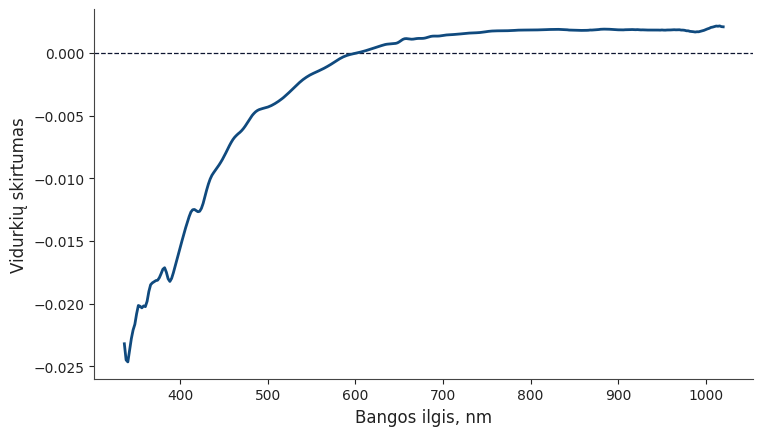

In [7]:
mu0 = F[y == 0].mean(axis=0)
mu1 = F[y == 1].mean(axis=0)
delta = mu1 - mu0

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.axhline(0, color=COLOR_DARK, lw=0.9, linestyle="--")
ax.plot(wavelengths, delta, lw=2.0, color=COLOR_PRIMARY)
ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Vidurkių skirtumas")
apply_clean_axes(ax, add_grid=False)
plt.show()


  ## 7. Load predefined repeated stratified splits

In [8]:
with open(split_path) as f:
    splits = json.load(f)

if SMOKE:
    splits = {k: v for k, v in splits.items() if k.startswith("rep0_")}
    print(f"SMOKE mode: using {len(splits)} splits")
else:
    print(f"Full mode: using {len(splits)} splits")

split_names = sorted(splits.keys(), key=split_sort_key)
print(f"Loaded {len(split_names)} splits")


Full mode: using 50 splits
Loaded 50 splits


  ## 8. Helper functions

In [9]:
def normalize_scores_train_ref(scores_te: np.ndarray, scores_tr: np.ndarray) -> np.ndarray:
    lo, hi = float(scores_tr.min()), float(scores_tr.max())
    if hi == lo:
        return np.full_like(scores_te, 0.5, dtype=np.float64)
    out = ((scores_te - lo) / (hi - lo)).astype(np.float64)
    return np.clip(out, 0.0, 1.0)


def pick_youden_threshold(y_true: np.ndarray, y_prob: np.ndarray, grid_size: int = 200) -> float:
    thresholds = np.linspace(0, 1, grid_size)
    best_j, best_thr = -1.0, 0.5

    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        sens = tp / (tp + fn) if (tp + fn) else 0.0
        spec = tn / (tn + fp) if (tn + fp) else 0.0
        j = sens + spec - 1.0
        if j > best_j:
            best_j, best_thr = j, float(thr)

    return best_thr


def fold_metrics(
    y_true_te: np.ndarray,
    y_score_te: np.ndarray,
    y_true_tr: np.ndarray,
    y_score_tr: np.ndarray,
):
    out = {"pr_auc": average_precision_score(y_true_te, y_score_te)}

    try:
        out["roc_auc"] = float(roc_auc_score(y_true_te, y_score_te))
    except ValueError:
        out["roc_auc"] = np.nan

    prob_tr = normalize_scores_train_ref(y_score_tr, y_score_tr)
    prob_te = normalize_scores_train_ref(y_score_te, y_score_tr)
    thr = pick_youden_threshold(y_true_tr, prob_tr)
    y_pred = (prob_te >= thr).astype(np.int64)

    out["youden_threshold"] = thr
    out["sensitivity"] = recall_score(y_true_te, y_pred, pos_label=1, zero_division=0)
    out["precision"] = precision_score(y_true_te, y_pred, pos_label=1, zero_division=0)
    out["specificity"] = recall_score(y_true_te, y_pred, pos_label=0, zero_division=0)
    out["accuracy"] = accuracy_score(y_true_te, y_pred)
    out["f1"] = f1_score(y_true_te, y_pred, pos_label=1, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_true_te, y_pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    out["youden_j"] = sens + spec - 1.0

    return out


def projection_fpca(F_tr_c, F_te_c, J):
    pca = PCA(n_components=J, random_state=RANDOM_STATE)
    xi_tr = pca.fit_transform(F_tr_c)
    xi_te = pca.transform(F_te_c)
    return xi_tr, xi_te


def projection_fpls(F_tr_c, F_te_c, y_tr, J):
    pls = PLSRegression(n_components=J)
    pls.fit(F_tr_c, y_tr)
    xi_tr = pls.transform(F_tr_c)
    xi_te = pls.transform(F_te_c)
    return xi_tr, xi_te


def centroid_scores(xi_tr, y_tr, xi_te):
    mu_b = xi_tr[y_tr == 1].mean(axis=0)
    mu_s = xi_tr[y_tr == 0].mean(axis=0)
    return np.sum((xi_te - mu_s) ** 2, axis=1) - np.sum((xi_te - mu_b) ** 2, axis=1)


def knn_scores(xi_tr, y_tr, xi_te, k=5, weighted=False):
    nn = NearestNeighbors(n_neighbors=k, metric="euclidean")
    nn.fit(xi_tr)

    d_te, idx_te = nn.kneighbors(xi_te)
    y_nn_te = y_tr[idx_te]

    if weighted:
        w_te = 1.0 / np.maximum(d_te, 1e-12)
        score_te = (w_te * y_nn_te).sum(axis=1) / w_te.sum(axis=1)
    else:
        score_te = y_nn_te.mean(axis=1)

    nn_tr = NearestNeighbors(n_neighbors=k + 1, metric="euclidean")
    nn_tr.fit(xi_tr)
    d_tr, idx_tr = nn_tr.kneighbors(xi_tr)

    d_tr = d_tr[:, 1:]
    idx_tr = idx_tr[:, 1:]
    y_nn_tr = y_tr[idx_tr]

    if weighted:
        w_tr = 1.0 / np.maximum(d_tr, 1e-12)
        score_tr = (w_tr * y_nn_tr).sum(axis=1) / w_tr.sum(axis=1)
    else:
        score_tr = y_nn_tr.mean(axis=1)

    return score_tr.astype(np.float64), score_te.astype(np.float64)


def summarise_run(df_run: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    metric_cols = [
        "pr_auc", "roc_auc", "sensitivity", "precision", "specificity",
        "accuracy", "f1", "youden_j", "youden_threshold"
    ]

    agg_dict = {}
    for m in metric_cols:
        agg_dict[f"{m}_mean"] = pd.NamedAgg(column=m, aggfunc="mean")
        agg_dict[f"{m}_std"] = pd.NamedAgg(column=m, aggfunc="std")

    return df_run.groupby(group_cols).agg(**agg_dict).reset_index()


def make_best_models_table(df_agg: pd.DataFrame) -> pd.DataFrame:
    best_by_rep = (
        df_agg.sort_values(["method_family", "f1_mean", "pr_auc_mean"], ascending=[True, False, False])
        .groupby("method_family", as_index=False)
        .first()
    )

    best_by_clf = (
        df_agg.sort_values(["classifier", "f1_mean", "pr_auc_mean"], ascending=[True, False, False])
        .groupby("classifier", as_index=False)
        .first()
    )

    best_by_rep["selection_type"] = "best_by_representation"
    best_by_rep["selection_name"] = best_by_rep["method_family"]

    best_by_clf["selection_type"] = "best_by_classifier"
    best_by_clf["selection_name"] = best_by_clf["classifier"]

    keep_cols = [
        "selection_type", "selection_name", "method_family", "classifier", "J",
        "pr_auc_mean", "pr_auc_std", "roc_auc_mean", "roc_auc_std", "f1_mean", "f1_std"
    ]

    return pd.concat(
        [best_by_rep[keep_cols], best_by_clf[keep_cols]],
        ignore_index=True,
    )


  ## 9. Run FPCA and FPLS experiments across classifier families

In [10]:
records = []

print(f"--- Starting evaluation for {len(split_names)} splits ---")

for sname in split_names:
    print(f"\nProcessing split: {sname}")

    tr_idx = np.array(splits[sname]["train"], dtype=int)
    te_idx = np.array(splits[sname]["test"], dtype=int)

    F_tr = F[tr_idx]
    F_te = F[te_idx]
    y_tr = y[tr_idx]
    y_te = y[te_idx]

    mu_train = F_tr.mean(axis=0)
    F_tr_c = F_tr - mu_train
    F_te_c = F_te - mu_train

    max_allowed_j = min(F_tr_c.shape[0] - 1, F_tr_c.shape[1])

    for J in J_VALUES:
        if J > max_allowed_j:
            continue

        print(f"  > J={J}: FPCA + FPLS")

        for method_family in ["FPCA", "FPLS"]:
            if method_family == "FPCA":
                xi_tr, xi_te = projection_fpca(F_tr_c, F_te_c, J)
            else:
                xi_tr, xi_te = projection_fpls(F_tr_c, F_te_c, y_tr, J)

            sc_tr = centroid_scores(xi_tr, y_tr, xi_tr)
            sc_te = centroid_scores(xi_tr, y_tr, xi_te)
            met = fold_metrics(y_te, sc_te, y_tr, sc_tr)
            records.append({
                "split": sname,
                "method_family": method_family,
                "J": J,
                "classifier": "centroid",
                **met,
            })

            sc_tr, sc_te = knn_scores(xi_tr, y_tr, xi_te, k=K_KNN, weighted=False)
            met = fold_metrics(y_te, sc_te, y_tr, sc_tr)
            records.append({
                "split": sname,
                "method_family": method_family,
                "J": J,
                "classifier": "knn",
                **met,
            })

            sc_tr, sc_te = knn_scores(xi_tr, y_tr, xi_te, k=K_KNN, weighted=True)
            met = fold_metrics(y_te, sc_te, y_tr, sc_tr)
            records.append({
                "split": sname,
                "method_family": method_family,
                "J": J,
                "classifier": "weighted_knn",
                **met,
            })

            lr = LogisticRegression(
                class_weight="balanced",
                max_iter=5000,
                random_state=RANDOM_STATE,
            )
            lr.fit(xi_tr, y_tr)
            sc_tr = lr.decision_function(xi_tr)
            sc_te = lr.decision_function(xi_te)
            met = fold_metrics(y_te, sc_te, y_tr, sc_tr)
            records.append({
                "split": sname,
                "method_family": method_family,
                "J": J,
                "classifier": "lr",
                **met,
            })

            svm = LinearSVC(
                C=1.0,
                class_weight="balanced",
                max_iter=10000,
                random_state=RANDOM_STATE,
            )
            svm.fit(xi_tr, y_tr)
            sc_tr = svm.decision_function(xi_tr)
            sc_te = svm.decision_function(xi_te)
            met = fold_metrics(y_te, sc_te, y_tr, sc_tr)
            records.append({
                "split": sname,
                "method_family": method_family,
                "J": J,
                "classifier": "linear_svm",
                **met,
            })

print("\n--- All evaluations finished ---")
df_run = pd.DataFrame(records)
display(df_run.head())


--- Starting evaluation for 50 splits ---

Processing split: rep0_fold0
  > J=1: FPCA + FPLS
  > J=2: FPCA + FPLS
  > J=3: FPCA + FPLS
  > J=5: FPCA + FPLS
  > J=10: FPCA + FPLS
  > J=15: FPCA + FPLS

Processing split: rep0_fold1
  > J=1: FPCA + FPLS
  > J=2: FPCA + FPLS
  > J=3: FPCA + FPLS
  > J=5: FPCA + FPLS
  > J=10: FPCA + FPLS
  > J=15: FPCA + FPLS

Processing split: rep0_fold2
  > J=1: FPCA + FPLS
  > J=2: FPCA + FPLS
  > J=3: FPCA + FPLS
  > J=5: FPCA + FPLS
  > J=10: FPCA + FPLS
  > J=15: FPCA + FPLS

Processing split: rep0_fold3
  > J=1: FPCA + FPLS
  > J=2: FPCA + FPLS
  > J=3: FPCA + FPLS
  > J=5: FPCA + FPLS
  > J=10: FPCA + FPLS
  > J=15: FPCA + FPLS

Processing split: rep0_fold4
  > J=1: FPCA + FPLS
  > J=2: FPCA + FPLS
  > J=3: FPCA + FPLS
  > J=5: FPCA + FPLS
  > J=10: FPCA + FPLS
  > J=15: FPCA + FPLS

Processing split: rep1_fold0
  > J=1: FPCA + FPLS
  > J=2: FPCA + FPLS
  > J=3: FPCA + FPLS
  > J=5: FPCA + FPLS
  > J=10: FPCA + FPLS
  > J=15: FPCA + FPLS

Processin

,split,method_family,J,classifier,pr_auc,roc_auc,youden_threshold,sensitivity,precision,specificity,accuracy,f1,youden_j
0,rep0_fold0,FPCA,1,centroid,0.292695,0.640457,0.010050,0.819820,0.259259,0.424779,0.502664,0.393939,0.244599
1,rep0_fold0,FPCA,1,knn,0.214514,0.524436,0.005025,0.648649,0.211144,0.404867,0.452931,0.318584,0.053516
2,rep0_fold0,FPCA,1,weighted_knn,0.221288,0.521038,0.115578,0.468468,0.192593,0.517699,0.507993,0.272966,-0.013832
3,rep0_fold0,FPCA,1,lr,0.292695,0.640457,0.010050,0.819820,0.259259,0.424779,0.502664,0.393939,0.244599
4,rep0_fold0,FPCA,1,linear_svm,0.292695,0.640457,0.010050,0.819820,0.259259,0.424779,0.502664,0.393939,0.244599


  ## 10. Summary tables

In [11]:
df_agg = summarise_run(df_run, ["method_family", "J", "classifier"])
best_models_df = make_best_models_table(df_agg)
DISPLAY_METHOD_NAMES = {
    "FPCA": "FPCA",
    "FPLS": "FPLS",
}

rank_by_f1 = df_agg.sort_values(
    ["f1_mean", "pr_auc_mean", "roc_auc_mean"],
    ascending=False
).reset_index(drop=True)

rank_by_f1_display = rank_by_f1.copy()
rank_by_f1_display["method_family"] = rank_by_f1_display["method_family"].map(DISPLAY_METHOD_NAMES)

print("\n=== TOP 15 BY F1 ===")
display(rank_by_f1_display[
    ["method_family", "J", "classifier", "f1_mean", "pr_auc_mean", "roc_auc_mean"]
].head(15))

best_models_display = best_models_df.copy()
best_models_display["method_family"] = best_models_display["method_family"].map(DISPLAY_METHOD_NAMES)
best_models_display["selection_name"] = best_models_display["selection_name"].replace(DISPLAY_METHOD_NAMES)

print("\n=== BEST MODELS TABLE ===")
display(best_models_display)



=== TOP 15 BY F1 ===


,method_family,J,classifier,f1_mean,pr_auc_mean,roc_auc_mean
0,FPLS,5,linear_svm,0.811313,0.870002,0.931923
1,FPLS,5,lr,0.809099,0.869331,0.931900
2,FPLS,10,lr,0.795228,0.868294,0.932527
3,FPLS,10,linear_svm,0.792565,0.866064,0.931513
4,FPLS,15,lr,0.786889,0.868051,0.934860
5,FPLS,15,linear_svm,0.782889,0.865577,0.933985
6,FPLS,5,weighted_knn,0.756538,0.794761,0.894396
7,FPLS,15,weighted_knn,0.746835,0.792103,0.890981
8,FPLS,5,knn,0.746743,0.768453,0.892848
9,FPLS,10,weighted_knn,0.746497,0.792636,0.891980



=== BEST MODELS TABLE ===


,selection_type,selection_name,method_family,classifier,J,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,f1_mean,f1_std
0,best_by_representation,FPCA,FPCA,linear_svm,15,0.656393,0.042532,0.852703,0.019012,0.597005,0.031726
1,best_by_representation,FPLS,FPLS,linear_svm,5,0.870002,0.030436,0.931923,0.014513,0.811313,0.027212
2,best_by_classifier,centroid,FPLS,centroid,3,0.655462,0.045031,0.851376,0.022631,0.584691,0.044648
3,best_by_classifier,knn,FPLS,knn,5,0.768453,0.033866,0.892848,0.016036,0.746743,0.026335
4,best_by_classifier,linear_svm,FPLS,linear_svm,5,0.870002,0.030436,0.931923,0.014513,0.811313,0.027212
5,best_by_classifier,lr,FPLS,lr,5,0.869331,0.030355,0.931900,0.014549,0.809099,0.027177
6,best_by_classifier,weighted_knn,FPLS,weighted_knn,5,0.794761,0.033247,0.894396,0.016256,0.756538,0.030322


  ## 11. PR-AUC and F1 vs J

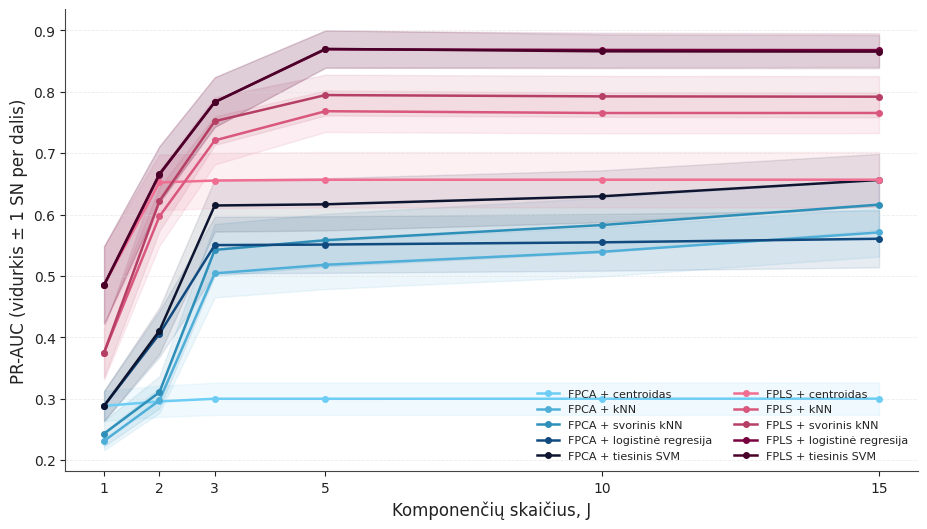

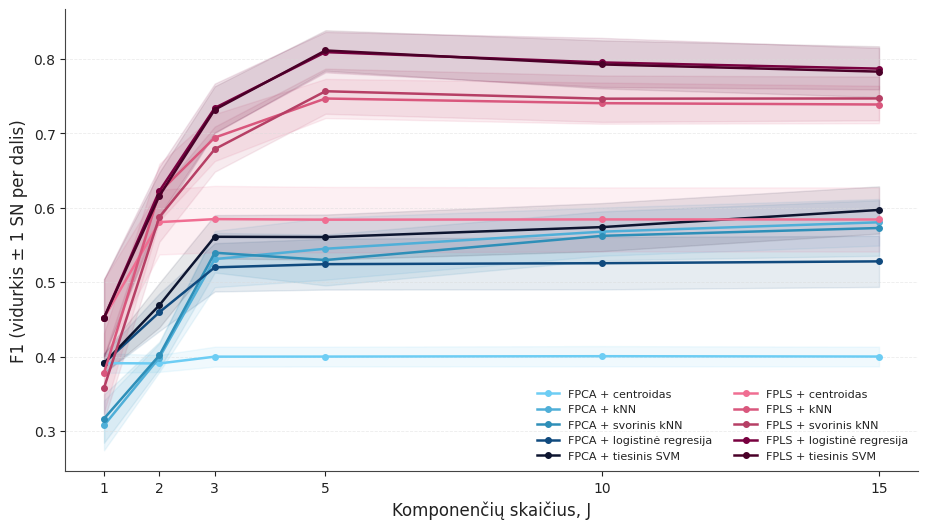

In [12]:
def plot_metric_vs_J(metric_key: str, ylabel: str):
    fig, ax = plt.subplots(figsize=(11, 6))

    for family in ["FPCA", "FPLS"]:
        for clf in CLASSIFIERS:
            sub = df_run[
                (df_run["method_family"] == family) &
                (df_run["classifier"] == clf)
            ]
            pivot_m = sub.groupby("J")[metric_key].mean().reindex(J_VALUES)
            pivot_s = sub.groupby("J")[metric_key].std().reindex(J_VALUES)

            m = pivot_m.values
            s = pivot_s.values

            ax.plot(
                J_VALUES,
                m,
                "o-",
                color=PLOT_COLORS[(family, clf)],
                label=PLOT_LABELS[(family, clf)],
                ms=4,
                linewidth=1.8,
            )
            ax.fill_between(
                J_VALUES,
                m - s,
                m + s,
                color=PLOT_COLORS[(family, clf)],
                alpha=0.10,
            )

    ax.set_xlabel("Komponenčių skaičius, J")
    ax.set_ylabel(ylabel)
    ax.set_xticks(J_VALUES)
    ax.legend(loc="best", fontsize=8, ncol=2, frameon=False)
    apply_clean_axes(ax, add_grid=True, grid_axis="y")
    plt.show()


plot_metric_vs_J(
    "pr_auc",
    "PR-AUC (vidurkis ± 1 SN per dalis)",
)

plot_metric_vs_J(
    "f1",
    "F1 (vidurkis ± 1 SN per dalis)",
)


  ## 12. Best FPCA vs best FPLS

In [13]:
fpca_best = rank_by_f1[rank_by_f1["method_family"] == "FPCA"].head(1).copy()
fpls_best = rank_by_f1[rank_by_f1["method_family"] == "FPLS"].head(1).copy()

if len(fpca_best):
    print("\nBest FPCA:")
    display(fpca_best[["method_family", "J", "classifier", "f1_mean", "pr_auc_mean", "roc_auc_mean"]])

if len(fpls_best):
    print("\nBest FPLS:")
    display(fpls_best[["method_family", "J", "classifier", "f1_mean", "pr_auc_mean", "roc_auc_mean"]])



Best FPCA:


,method_family,J,classifier,f1_mean,pr_auc_mean,roc_auc_mean
19,FPCA,15,linear_svm,0.597005,0.656393,0.852703



Best FPLS:


,method_family,J,classifier,f1_mean,pr_auc_mean,roc_auc_mean
0,FPLS,5,linear_svm,0.811313,0.870002,0.931923


  ## 13. 2D visualisation of class separation for best FPCA and best FPLS settings

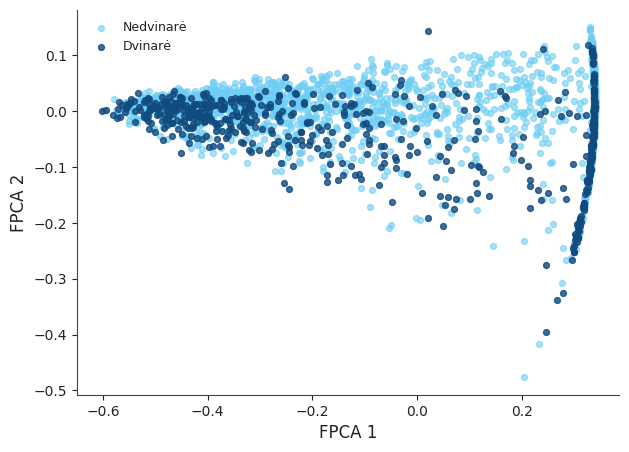

NameError: name 'fpls_scores_vis' is not defined

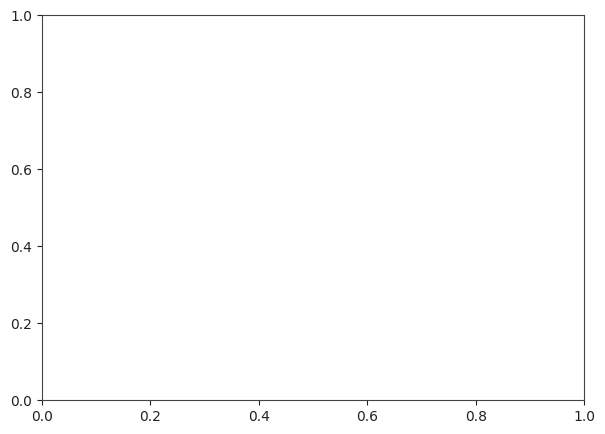

In [ ]:
best_fpca_j = int(fpca_best.iloc[0]["J"]) if len(fpca_best) else 2
best_fpls_j = int(fpls_best.iloc[0]["J"]) if len(fpls_best) else 2

F_centered = F - F.mean(axis=0)

pca_vis = PCA(n_components=2, random_state=RANDOM_STATE)
fpca_scores_vis = pca_vis.fit_transform(F_centered)

# --- FPCA ---
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    fpca_scores_vis[y == 0, 0],
    fpca_scores_vis[y == 0, 1],
    s=18,
    alpha=0.6,
    label="Nedvinarė",
    color="#6DCDF4",  # light blue
)

ax.scatter(
    fpca_scores_vis[y == 1, 0],
    fpca_scores_vis[y == 1, 1],
    s=18,
    alpha=0.8,
    label="Dvinarė",
    color="#104A7E",  # dark blue
)

ax.set_xlabel("FPCA 1")
ax.set_ylabel("FPCA 2")
ax.legend(frameon=False, loc="best")
apply_clean_axes(ax, add_grid=False)
plt.show()


# --- FPLS ---
fig, ax = plt.subplots(figsize=(7, 5))

best_fpca_j = int(fpca_best.iloc[0]["J"]) if len(fpca_best) else 2
best_fpls_j = int(fpls_best.iloc[0]["J"]) if len(fpls_best) else 2

F_centered = F - F.mean(axis=0)

pca_vis = PCA(n_components=2, random_state=RANDOM_STATE)
fpca_scores_vis = pca_vis.fit_transform(F_centered)

pls_vis = PLSRegression(n_components=2)
pls_vis.fit(F_centered, y)
fpls_scores_vis = pls_vis.transform(F_centered)

# --- FPCA ---
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    fpca_scores_vis[y == 0, 0],
    fpca_scores_vis[y == 0, 1],
    s=18,
    alpha=0.6,
    label="Nedvinarė",
    color="#6DCDF4",
)

ax.scatter(
    fpca_scores_vis[y == 1, 0],
    fpca_scores_vis[y == 1, 1],
    s=18,
    alpha=0.8,
    label="Dvinarė",
    color="#104A7E",
)

ax.set_xlabel("FPCA 1")
ax.set_ylabel("FPCA 2")
ax.legend(frameon=False, loc="best")
apply_clean_axes(ax, add_grid=False)
plt.show()


# --- FPLS ---
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    fpls_scores_vis[y == 0, 0],
    fpls_scores_vis[y == 0, 1],
    s=18,
    alpha=0.6,
    label="Nedvinarė",
    color="#F06E92",
)

ax.scatter(
    fpls_scores_vis[y == 1, 0],
    fpls_scores_vis[y == 1, 1],
    s=18,
    alpha=0.8,
    label="Dvinarė",
    color="#78003F",
)

ax.set_xlabel("FPLS 1")
ax.set_ylabel("FPLS 2")
ax.legend(frameon=False, loc="best")
apply_clean_axes(ax, add_grid=False)
plt.show()

ax.scatter(
    fpls_scores_vis[y == 1, 0],
    fpls_scores_vis[y == 1, 1],
    s=18,
    alpha=0.8,
    label="Dvinarė",
    color="#78003F",  # burgundy
)

ax.set_xlabel("FPLS 1")
ax.set_ylabel("FPLS 2")
ax.legend(frameon=False, loc="best")
apply_clean_axes(ax, add_grid=False)
plt.show()

  ## 14. Save main outputs

In [15]:
df_run.to_csv(OUT_DIR / "fpca_fpls_fold_metrics.csv", index=False)
df_agg.to_csv(OUT_DIR / "fpca_fpls_summary.csv", index=False)
best_models_df.to_csv(OUT_DIR / "fpca_fpls_best_models.csv", index=False)

print("Saved main CSV outputs to:", OUT_DIR)


PermissionError: [Errno 13] Permission denied: 'c:\\Users\\Lenovo\\Documents\\VDA\\Bakalauras\\Kodas\\results\\03_fpca_vs_fpls\\fpca_fpls_summary.csv'

  ## 15. Save figures

In [ ]:
# Mean shape difference
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.axhline(0, color=COLOR_DARK, lw=0.9, linestyle="--")
ax.plot(wavelengths, delta, lw=2.0, color=COLOR_PRIMARY)
ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Vidurkių skirtumas")
apply_clean_axes(ax, add_grid=False)
save_fig(OUT_DIR / "fig_mean_shape_difference.svg")

# PR-AUC vs J
fig, ax = plt.subplots(figsize=(11, 6))
for family in ["FPCA", "FPLS"]:
    for clf in CLASSIFIERS:
        sub = df_run[
            (df_run["method_family"] == family) &
            (df_run["classifier"] == clf)
        ]
        pivot_m = sub.groupby("J")["pr_auc"].mean().reindex(J_VALUES)
        pivot_s = sub.groupby("J")["pr_auc"].std().reindex(J_VALUES)

        m = pivot_m.values
        s = pivot_s.values

        ax.plot(
            J_VALUES,
            m,
            "o-",
            color=PLOT_COLORS[(family, clf)],
            label=PLOT_LABELS[(family, clf)],
            ms=4,
            linewidth=1.8,
        )
        ax.fill_between(
            J_VALUES,
            m - s,
            m + s,
            color=PLOT_COLORS[(family, clf)],
            alpha=0.10,
        )

ax.set_xlabel("Komponenčių skaičius, J")
ax.set_ylabel("PR-AUC (vidurkis ± 1 SN per dalis)")
ax.set_xticks(J_VALUES)
ax.legend(loc="best", fontsize=8, ncol=2, frameon=False)
apply_clean_axes(ax, add_grid=True, grid_axis="y")
save_fig(OUT_DIR / "fig_pr_auc_vs_j.svg")

# F1 vs J
fig, ax = plt.subplots(figsize=(11, 6))
for family in ["FPCA", "FPLS"]:
    for clf in CLASSIFIERS:
        sub = df_run[
            (df_run["method_family"] == family) &
            (df_run["classifier"] == clf)
        ]
        pivot_m = sub.groupby("J")["f1"].mean().reindex(J_VALUES)
        pivot_s = sub.groupby("J")["f1"].std().reindex(J_VALUES)

        m = pivot_m.values
        s = pivot_s.values

        ax.plot(
            J_VALUES,
            m,
            "o-",
            color=PLOT_COLORS[(family, clf)],
            label=PLOT_LABELS[(family, clf)],
            ms=4,
            linewidth=1.8,
        )
        ax.fill_between(
            J_VALUES,
            m - s,
            m + s,
            color=PLOT_COLORS[(family, clf)],
            alpha=0.10,
        )

ax.set_xlabel("Komponenčių skaičius, J")
ax.set_ylabel("F1 (vidurkis ± 1 SN per dalis)")
ax.set_xticks(J_VALUES)
ax.legend(loc="best", fontsize=8, ncol=2, frameon=False)
apply_clean_axes(ax, add_grid=True, grid_axis="y")
save_fig(OUT_DIR / "fig_f1_vs_j.svg")

# FPCA 2D
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(fpca_scores_vis[y == 0, 0], fpca_scores_vis[y == 0, 1], s=18, alpha=0.7, label="Nedvinarė", color=COLOR_SECONDARY)
ax.scatter(fpca_scores_vis[y == 1, 0], fpca_scores_vis[y == 1, 1], s=18, alpha=0.7, label="Dvinarė", color=COLOR_PRIMARY)
ax.set_xlabel("FPCA 1")
ax.set_ylabel("FPCA 2")
ax.legend(frameon=False, loc="best")
apply_clean_axes(ax, add_grid=False)
save_fig(OUT_DIR / "fig_fpca_2d_visualisation.svg")

# FPLS 2D
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(fpls_scores_vis[y == 0, 0], fpls_scores_vis[y == 0, 1], s=18, alpha=0.7, label="Nedvinarė", color=COLOR_SECONDARY)
ax.scatter(fpls_scores_vis[y == 1, 0], fpls_scores_vis[y == 1, 1], s=18, alpha=0.7, label="Dvinarė", color=COLOR_PRIMARY)
ax.set_xlabel("FPLS 1")
ax.set_ylabel("FPLS 2")
ax.legend(frameon=False, loc="best")
apply_clean_axes(ax, add_grid=False)
save_fig(OUT_DIR / "fig_fpls_2d_visualisation.svg")

print("Saved figure outputs to:", OUT_DIR)


Saved figure outputs to: c:\Users\Lenovo\Documents\VDA\Bakalauras\Kodas\results\03_fpca_vs_fpls


  ## 16. Final quick view

In [ ]:
pretty_best = best_models_df.copy()
pretty_best["PR-AUC"] = [ms(m, s) for m, s in zip(pretty_best["pr_auc_mean"], pretty_best["pr_auc_std"])]
pretty_best["ROC-AUC"] = [ms(m, s) for m, s in zip(pretty_best["roc_auc_mean"], pretty_best["roc_auc_std"])]
pretty_best["F1"] = [ms(m, s) for m, s in zip(pretty_best["f1_mean"], pretty_best["f1_std"])]

display(
    pretty_best[
        ["selection_type", "selection_name", "method_family", "classifier", "J", "PR-AUC", "ROC-AUC", "F1"]
    ]
)

,selection_type,selection_name,method_family,classifier,J,PR-AUC,ROC-AUC,F1
0,best_by_representation,FPCA,FPCA,linear_svm,15,0.6564 ± 0.0425,0.8527 ± 0.0190,0.5970 ± 0.0317
1,best_by_representation,FPLS,FPLS,linear_svm,5,0.8700 ± 0.0304,0.9319 ± 0.0145,0.8113 ± 0.0272
2,best_by_classifier,centroid,FPLS,centroid,3,0.6555 ± 0.0450,0.8514 ± 0.0226,0.5847 ± 0.0446
3,best_by_classifier,knn,FPLS,knn,5,0.7685 ± 0.0339,0.8928 ± 0.0160,0.7467 ± 0.0263
4,best_by_classifier,linear_svm,FPLS,linear_svm,5,0.8700 ± 0.0304,0.9319 ± 0.0145,0.8113 ± 0.0272
5,best_by_classifier,lr,FPLS,lr,5,0.8693 ± 0.0304,0.9319 ± 0.0145,0.8091 ± 0.0272
6,best_by_classifier,weighted_knn,FPLS,weighted_knn,5,0.7948 ± 0.0332,0.8944 ± 0.0163,0.7565 ± 0.0303
